# Connectivity motifs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

In [2]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 18,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    # "figure.figsize": (16, 6)       # Figsize
    "figure.figsize": (8, 6)       # Figsize
})

In [3]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 16,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 18,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
})

In [4]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# Dataframe

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    # fig, axs = plt.subplots(1, 4, figsize=(16, 6), sharey=True)



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        display(df_results)


        sorted = df_results.sort_values(by=['pqif', 'seed'])

        # if sim == simulation_number[0]:
        #     display(sorted)

        # for pqif, name in zip(pqif_values, names):
        for pqif in pqif_values:

            # df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15) & (df_results['seed']==0)]
            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)] 


            # display(df_filtered)

# display(test_1)
# display(test_2)

,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.50,0,0,0.236176,0.009178,0.000324,-0.005025,-0.000092
1,0.50,0,1,13.537842,-0.048553,0.000409,-0.004501,0.000343
2,0.50,0,2,14.106071,-0.041677,0.000641,-0.004575,0.000269
3,0.50,0,3,13.849741,-0.042772,0.000515,-0.004652,0.000178
4,0.50,0,4,13.549768,-0.048212,0.000626,-0.004682,0.000180
...,...,...,...,...,...,...,...,...
3995,0.25,49,11,11.751163,-0.041408,0.000289,-0.004859,0.000527
3996,0.25,49,12,11.751163,-0.041408,0.000289,-0.004859,0.000527
3997,0.25,49,13,11.751163,-0.041408,0.000289,-0.004859,0.000527
3998,0.25,49,14,11.751163,-0.041408,0.000289,-0.004859,0.000527


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.5,0,0,0.239773,-0.007684,0.000050,-0.005025,0.000077
1,0.5,0,1,16.158884,-0.034596,0.000732,-0.004803,0.000508
2,0.5,0,2,16.900833,-0.025606,0.000277,-0.004743,0.000591
3,0.5,0,3,16.320832,-0.027339,0.000512,-0.004721,0.000498
4,0.5,0,4,15.757425,-0.034589,0.000431,-0.004705,0.000813
...,...,...,...,...,...,...,...,...
3995,1.0,49,11,17.923280,-0.078608,0.000407,-0.004597,0.001185
3996,1.0,49,12,17.923280,-0.078608,0.000407,-0.004597,0.001185
3997,1.0,49,13,17.923280,-0.078608,0.000407,-0.004597,0.001185
3998,1.0,49,14,17.923280,-0.078608,0.000407,-0.004597,0.001185


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.5,0,0,0.246779,-0.004773,-0.000743,-0.005025,0.000048
1,0.5,0,1,18.781036,-0.035468,0.000806,-0.004797,0.000758
2,0.5,0,2,20.393816,-0.019026,0.000779,-0.004800,0.000537
3,0.5,0,3,19.573600,-0.022173,0.000921,-0.004782,0.000372
4,0.5,0,4,18.906068,-0.023066,0.001093,-0.004810,0.000530
...,...,...,...,...,...,...,...,...
3995,1.0,49,11,16.485589,-0.090120,0.000113,-0.004820,0.000903
3996,1.0,49,12,16.485589,-0.090120,0.000113,-0.004820,0.000903
3997,1.0,49,13,16.485589,-0.090120,0.000113,-0.004820,0.000903
3998,1.0,49,14,16.485589,-0.090120,0.000113,-0.004820,0.000903


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.0,0,0,0.241489,-0.002613,-0.000254,-0.005025,0.000026
1,0.0,0,1,23.798484,0.013733,-0.000324,-0.004967,-0.000232
2,0.0,0,2,23.974474,0.026752,0.000021,-0.004967,-0.000309
3,0.0,0,3,22.850809,0.029571,-0.000001,-0.004973,-0.000344
4,0.0,0,4,22.333228,0.026687,0.000177,-0.004974,-0.000242
...,...,...,...,...,...,...,...,...
3995,1.0,49,11,15.901976,-0.081580,0.000474,-0.004744,0.000961
3996,1.0,49,12,15.901976,-0.081580,0.000474,-0.004744,0.000961
3997,1.0,49,13,15.901976,-0.081580,0.000474,-0.004744,0.000961
3998,1.0,49,14,15.901976,-0.081580,0.000474,-0.004744,0.000961


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.25,0,0,0.244321,0.004476,0.000344,-0.005025,-0.000045
1,0.25,0,1,5.933954,0.045682,0.000280,-0.004836,-0.000475
2,0.25,0,2,6.796871,0.016720,0.003363,-0.004852,-0.000208
3,0.25,0,3,6.652310,0.009971,0.003198,-0.004880,-0.000044
4,0.25,0,4,7.229871,0.016930,0.003630,-0.004777,-0.000228
...,...,...,...,...,...,...,...,...
3995,0.50,49,11,7.706019,0.048653,0.011436,-0.004506,-0.001554
3996,0.50,49,12,7.706019,0.048653,0.011436,-0.004506,-0.001554
3997,0.50,49,13,7.706019,0.048653,0.011436,-0.004506,-0.001554
3998,0.50,49,14,7.706019,0.048653,0.011436,-0.004506,-0.001554


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.0,0,0,0.241246,0.001891,0.000842,-0.005025,-0.000019
1,0.0,0,1,8.475796,0.055187,-0.000066,-0.004996,-0.000604
2,0.0,0,2,9.410232,0.011441,0.001056,-0.004961,-0.000156
3,0.0,0,3,8.561243,0.010284,0.001859,-0.004923,-0.000274
4,0.0,0,4,8.223075,0.022830,0.001951,-0.004894,-0.000442
...,...,...,...,...,...,...,...,...
3995,1.0,49,11,7.199413,0.137411,0.009797,-0.004708,-0.002316
3996,1.0,49,12,7.199413,0.137411,0.009797,-0.004708,-0.002316
3997,1.0,49,13,7.199413,0.137411,0.009797,-0.004708,-0.002316
3998,1.0,49,14,7.199413,0.137411,0.009797,-0.004708,-0.002316


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.0,0,0,0.246889,-0.018418,0.000155,-0.005025,0.000185
1,0.0,0,1,11.344563,0.041151,-0.000429,-0.004982,-0.000461
2,0.0,0,2,12.128850,0.017966,0.000615,-0.004949,-0.000280
3,0.0,0,3,11.002558,0.034903,0.001839,-0.004877,-0.000462
4,0.0,0,4,11.479579,0.047602,0.002838,-0.004894,-0.000572
...,...,...,...,...,...,...,...,...
3995,0.5,49,11,8.805662,0.087472,0.010577,-0.004771,-0.001618
3996,0.5,49,12,8.805662,0.087472,0.010577,-0.004771,-0.001618
3997,0.5,49,13,8.805662,0.087472,0.010577,-0.004771,-0.001618
3998,0.5,49,14,8.805662,0.087472,0.010577,-0.004771,-0.001618


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
0,0.25,0,0,0.243724,0.000090,0.000311,-0.005025,-9.019170e-07
1,0.25,0,1,11.731384,0.013196,-0.000542,-0.004946,-2.225124e-04
2,0.25,0,2,11.701874,-0.003125,0.002436,-0.004917,-2.142172e-04
3,0.25,0,3,10.334223,0.032898,0.002057,-0.004879,-7.167934e-04
4,0.25,0,4,9.936135,0.050904,0.003572,-0.004859,-6.699227e-04
...,...,...,...,...,...,...,...,...
3995,1.00,49,11,8.180110,0.106381,0.019847,-0.004749,-3.119445e-03
3996,1.00,49,12,8.180110,0.106381,0.019847,-0.004749,-3.119445e-03
3997,1.00,49,13,8.180110,0.106381,0.019847,-0.004749,-3.119445e-03
3998,1.00,49,14,8.180110,0.106381,0.019847,-0.004749,-3.119445e-03


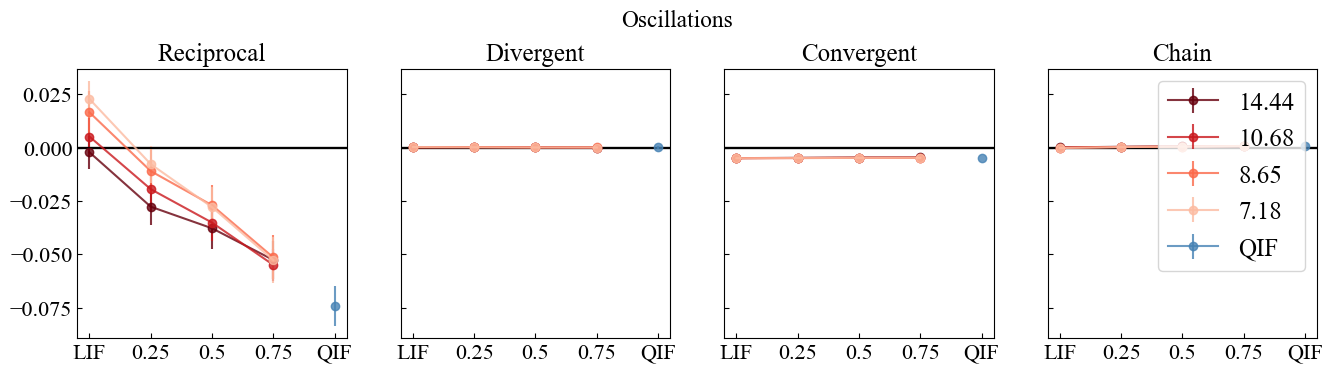

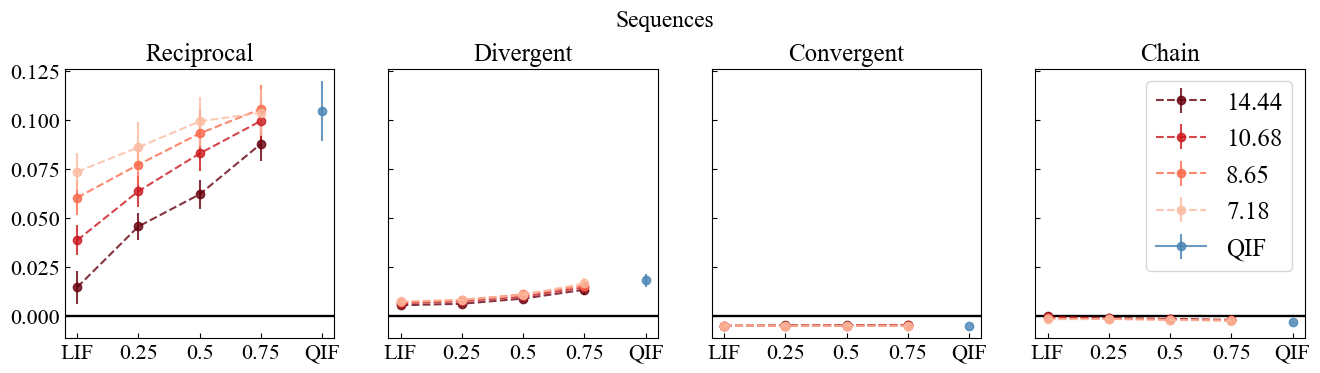

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            # df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15) & (df_results['seed']==0)]
            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                label=f,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            # axs[i].set_ylim()
            
    # TODO collapse all QIF and plot alone

    # QIF separate
    # TODO decide on a specific simulation?
    df_qif = df_results[(df_results['pqif'] == 1) & (df_results['nloop'] == 15)]  # is now a dataframe for QIF, with 50 seeds TODO

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    # x_qif = [1]  # QIF
    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    plt.legend()
    plt.suptitle(f"{dyn.capitalize()}")
    plt.show